# Artificial Neural Networks and Deep Learning

## Homework 2 - FORmidable
---

## ⚙️ Import Libraries

In [1]:
# All the comments in this notebook only corresponds to new parts, please refer to our baseline notebook for more details.
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'

import zipfile
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras as tfk
from keras import layers as tfkl
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
%matplotlib inline

os.environ["TF_GPU_ALLOCATOR"] = "cuda_malloc_async"
print(f"GPU devices: {len(tf.config.list_physical_devices('GPU'))}")

from keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')

np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version: {tfk.__version__}")

on_kaggle = True

GPU devices: 2
TensorFlow version: 2.16.1
Keras version: 3.3.3


## ⏳ Load and Visualize the Data

In [2]:
if (on_kaggle):
    %cd "/kaggle/input"
    data = np.load("mars-dataset/mars_for_students.npz")
else: 
    data = np.load("mars_for_students.npz")

training_set = data["training_set"]

X_train_original = training_set[:, 0]
y_train_original = training_set[:, 1]
X_test_original = data["test_set"]

print(f"Training X shape: {X_train_original.shape}")
print(f"Training y shape: {y_train_original.shape}")
print(f"Test X shape: {X_test_original.shape}")

/kaggle/input
Training X shape: (2615, 64, 128)
Training y shape: (2615, 64, 128)
Test X shape: (10022, 64, 128)


In [3]:
colors = ['black', 'saddlebrown', 'gray', 'khaki', 'blue']
label_names = ['background', 'soil', 'bedrock', 'sand', 'big rock']

cmap = plt.cm.colors.ListedColormap(colors)

def plot_image_label(images, labels, num_rows, num_cols, range_max):
    _, axes = plt.subplots(num_rows, 2 * num_cols, figsize=(4*num_cols, num_rows))
    
    for i in range(num_rows):
        for j in range(num_cols):
            idx = i * num_cols + j
            axes[i, j * 2].imshow(images[idx], cmap='gray', vmin=0, vmax=range_max)
            axes[i, j * 2].axis('off')
            axes[i, j * 2 + 1].imshow(labels[idx], cmap=cmap, vmin=0, vmax=4)
            axes[i, j * 2 + 1].axis('off')
    
    plt.tight_layout()
    plt.show()
    
#plot_image_label(X_train_original, y_train_original, 6, 3, 255)

In [4]:
def get_indices_to_remove(y_train, label_to_remove):
    y_reshaped = y_train.reshape(y_train.shape[0], -1)
    label_flat = label_to_remove.reshape(1, -1)
    indices_to_remove = np.where(np.all(y_reshaped == label_flat, axis=1))[0]
    return indices_to_remove

def remove_indices(X_train, y_train, indices_to_remove):
    mask = np.ones(X_train.shape[0], dtype=bool)
    mask[indices_to_remove] = False
    X_train_new = X_train[mask]
    y_train_new = y_train[mask]
    return X_train_new, y_train_new

label_to_remove = y_train_original[2561]

indices_to_remove = get_indices_to_remove(y_train_original, label_to_remove)
X_train_cleaned, y_train_cleaned = remove_indices(X_train_original, y_train_original, indices_to_remove)
print(f"Original train shape: {X_train_original.shape}, New shape: {X_train_cleaned.shape}")

X_train_original = X_train_cleaned
y_train_original = y_train_cleaned

Original train shape: (2615, 64, 128), New shape: (2505, 64, 128)


In [5]:
def plot_distribution(lbl):
    if isinstance(lbl, tf.Tensor):
        lbl = lbl.numpy()

    label_counts = np.bincount(lbl.flatten().astype(int))
    total_count = np.sum(label_counts)
    label_4_percentage = (label_counts[4] / total_count) * 100 if 4 < len(label_counts) else 0
    
    label_counts = np.bincount(lbl.flatten().astype(int))
    plt.figure(figsize=(7, 4))
    plt.bar(label_names, label_counts, color=colors)
    plt.xlabel("Labels")
    plt.ylabel("Count")
    plt.title("Label Distribution")

    if 4 < len(label_counts):
        plt.text(4, label_counts[4] + total_count * 0.02,
                 f"{label_4_percentage:.2f}%", 
                 ha='center', fontsize=10)
        
    plt.show()

## Prepare the dataset

In [6]:
BATCH_SIZE = 64
LEARNING_RATE = 1e-3
PATIENCE = 30
EPOCHS = 1000
SPLITS_SIZE = 300
SEED = 42

In [7]:
from sklearn.utils.class_weight import compute_class_weight

# Flatten the label array to get pixel-wise counts
flat_labels = y_train_original.flatten().astype(int)

# Compute the class weights using sklearn
class_labels = [0, 1, 2, 3, 4]  # Classes: Background, Soil, Bedrock, Sand, Big Rock
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=class_labels,
    y=flat_labels
)

# Convert the result into a dictionary
class_weights_dict = {i: weight for i, weight in enumerate(class_weights)}
#class_weights_dict[0] = 0
class_weights_dict[4] /= 20

print("Computed class weights:", class_weights_dict)

Computed class weights: {0: 0.8226769183771894, 1: 0.5898914242365618, 2: 0.8591909663562084, 3: 1.088407490884616, 4: 7.610785150020398}


In [8]:
def apply_preprocessing(images):
    images = images[..., tf.newaxis] / 255.0
    ret = []
    for image in images:
        mean_brightness = tf.reduce_mean(image)
        delta = 1.0 * (0.5 - mean_brightness)
        image = tf.image.adjust_brightness(image, delta=delta)
        image = tf.image.adjust_contrast(image, contrast_factor=3.0)
        image = tf.clip_by_value(image, 0.0, 1.0) 
        ret.append(image)
    return np.array(ret)

X_train = apply_preprocessing(X_train_original)
y_train = y_train_original[..., tf.newaxis]

X_train = tf.cast(X_train, tf.float32)
y_train = tf.cast(y_train, tf.int32)

In [9]:
train_img, val_img, train_lbl, val_lbl = train_test_split(X_train.numpy().squeeze(), y_train.numpy().squeeze(), test_size=SPLITS_SIZE)
print("Data splitted!")
print(f"\nNumber of images:")
print(f"Train: {len(train_img)}")
print(f"Validation: {len(val_img)}")

train_img = train_img[..., tf.newaxis]
val_img = val_img[..., tf.newaxis]
train_lbl = train_lbl[..., tf.newaxis]
val_lbl = val_lbl[..., tf.newaxis]

Data splitted!

Number of images:
Train: 2205
Validation: 300


In [10]:
def augment_images(image, label, n_aug_0123, n_aug_4, seed=SEED):
    n_augmentations = tf.cond(
        tf.reduce_any(tf.equal(label, 4)),
        lambda: tf.constant(n_aug_4), 
        lambda: tf.constant(n_aug_0123)      
    )

    augmented_images = tf.TensorArray(dtype=tf.float32, size=n_augmentations+1)
    augmented_labels = tf.TensorArray(dtype=tf.float32, size=n_augmentations+1)
    augmented_images = augmented_images.write(0, image)
    augmented_labels = augmented_labels.write(0, label)

    for i in tf.range(1, n_augmentations+1):
        augmented_image, augmented_label = image, label

        if tf.random.uniform(()) > 0.2:
            augmented_image = tf.image.flip_left_right(augmented_image)
            augmented_label = tf.image.flip_left_right(augmented_label)

        if tf.random.uniform(()) > 0.2:
            augmented_image = tf.image.flip_up_down(augmented_image)
            augmented_label = tf.image.flip_up_down(augmented_label)

        if tf.random.uniform(()) > 0.2:
            noise = tf.random.normal(shape=tf.shape(augmented_image), mean=0.0, stddev=0.008)
            augmented_image = tf.clip_by_value(augmented_image + noise, 0.0, 1.0)

        if tf.random.uniform(()) > 0.2:
            zoom_factor = tf.random.uniform([], minval=1, maxval=1.2, dtype=tf.float32, seed=seed)
            central_fraction = 1.0 / zoom_factor
            zoom_image = tf.image.central_crop(augmented_image, central_fraction)
            zoom_label = tf.image.central_crop(augmented_label, central_fraction)
            augmented_image = tf.image.resize(zoom_image, tf.shape(image)[0:2])
            augmented_label = tf.image.resize(zoom_label, tf.shape(label)[0:2])

        augmented_images = augmented_images.write(i, augmented_image)
        augmented_labels = augmented_labels.write(i, augmented_label)

    return augmented_images.stack(), augmented_labels.stack()

In [11]:
def make_dataset(images, labels, batch_size, shuffle, augment=False, n_aug0123=1, n_aug_4=2, seed=SEED):
    dataset = tf.data.Dataset.from_tensor_slices((images, labels))
    dataset = dataset.map(lambda image, label: (image, tf.cast(label, tf.float32)), num_parallel_calls=tf.data.AUTOTUNE)

    if augment:
        def augmentation_map(image, label):
            augmented_images, augmented_labels = augment_images(image, label, n_aug0123, n_aug_4, seed=seed)
            return tf.data.Dataset.from_tensor_slices((augmented_images, augmented_labels))
        dataset = dataset.flat_map(augmentation_map)
    
    dataset = dataset.map(lambda image, label: (image, tf.cast(label, tf.int32)), num_parallel_calls=tf.data.AUTOTUNE)
    
    if shuffle:
        dataset = dataset.shuffle(buffer_size=batch_size * 2, seed=seed)

    dataset = dataset.batch(batch_size, drop_remainder=False)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)
    return dataset

train_dataset = make_dataset(train_img, train_lbl, batch_size=BATCH_SIZE, shuffle=True, augment=True, n_aug0123=1, n_aug_4=1)
val_dataset = make_dataset(val_img, val_lbl, batch_size=BATCH_SIZE, shuffle=False)
print("Datasets created!")

for images, labels in train_dataset.take(1):
    input_shape = images.shape[1:]
    print(f"Input shape: {input_shape}")
    print("Images shape:", images.shape)
    print("Labels shape:", labels.shape)
    break

total_images = 0
for images, labels in train_dataset:
    total_images += images.shape[0]

print(f"Total number of images in train_dataset: {total_images}")

Datasets created!
Input shape: (64, 128, 1)
Images shape: (64, 64, 128, 1)
Labels shape: (64, 64, 128, 1)
Total number of images in train_dataset: 4410


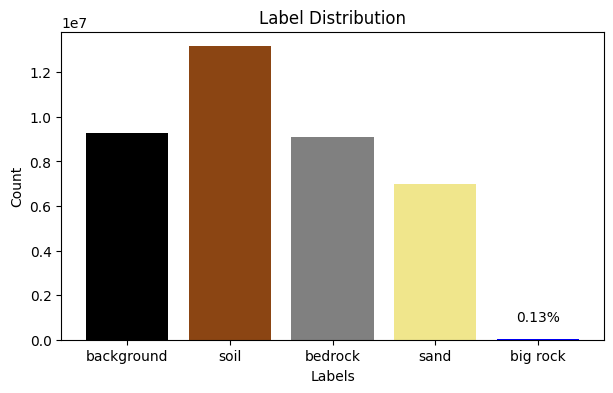

In [12]:
aug_labels = tf.concat(
    [
        tf.concat([labels for _, labels in train_dataset], axis=0),
        tf.concat([labels for _, labels in val_dataset], axis=0)
    ],
    axis=0
)

plot_distribution(aug_labels)

## 🛠️ Train and Save the Model

In [13]:
def enhanced_bottleneck(input_tensor, filters, name='bottleneck_'):
    """Enhanced bottleneck with simplified parallel dilated convolutions and SE mechanism."""
    # Parallel dilated convolutions
    conv1 = tfkl.Conv2D(filters, kernel_size=3, dilation_rate=1, padding='same', activation='relu', name=name + 'dilated1')(input_tensor)
    conv2 = tfkl.Conv2D(filters, kernel_size=3, dilation_rate=2, padding='same', activation='relu', name=name + 'dilated2')(input_tensor)
    conv3 = tfkl.Conv2D(filters, kernel_size=3, dilation_rate=4, padding='same', activation='relu', name=name + 'dilated3')(input_tensor)
    dilated_features = tfkl.Concatenate(name=name + 'concat')([conv1, conv2, conv3])

    # Squeeze-and-Excitation mechanism (simplified)
    se = tfkl.GlobalAveragePooling2D(name=name + 'se_gap')(dilated_features)
    se = tfkl.Dense(filters, activation='relu', name=name + 'se_dense1')(se)
    se = tfkl.Dense(filters * 3, activation='sigmoid', name=name + 'se_dense2')(se)
    se = tfkl.Reshape((1, 1, filters * 3), name=name + 'se_reshape')(se)
    se_features = tfkl.Multiply(name=name + 'se_scaled')([dilated_features, se])

    return se_features

def unet_block(input_tensor, filters, kernel_size=3, activation='relu', stack=2, name=''):
    """Define a UNet block with Conv2D, BatchNormalization, Activation, and Dropout."""
    x = input_tensor
    for i in range(stack):
        x = tfkl.Conv2D(filters, kernel_size=kernel_size, padding='same', name=name + 'conv' + str(i + 1))(x)
        x = tfkl.BatchNormalization(name=name + 'bn' + str(i + 1))(x)
        x = tfkl.Activation(activation, name=name + 'activation' + str(i + 1))(x)
    x = tfkl.Dropout(0.3)(x)  # Add dropout
    return x

def build_unet(input_tensor, num_classes, filters_base=64, name_prefix=''):
    """Define a single UNet."""
    # Downsampling
    down_block_1 = unet_block(input_tensor, filters_base, name=name_prefix + 'down_block1_')
    d1 = tfkl.MaxPooling2D()(down_block_1)
    
    down_block_2 = unet_block(d1, filters_base * 2, name=name_prefix + 'down_block2_')
    d2 = tfkl.MaxPooling2D()(down_block_2)

    # Enhanced Bottleneck
    bottleneck = enhanced_bottleneck(d2, filters_base * 4, name=name_prefix + 'bottleneck_')

    # Upsampling
    u1 = tfkl.UpSampling2D()(bottleneck)
    u1 = tfkl.Concatenate()([u1, down_block_2])
    up_block_1 = unet_block(u1, filters_base * 2, name=name_prefix + 'up_block1_')

    u2 = tfkl.UpSampling2D()(up_block_1)
    u2 = tfkl.Concatenate()([u2, down_block_1])
    up_block_2 = unet_block(u2, filters_base, name=name_prefix + 'up_block2_')

    # Output layer
    output = tfkl.Conv2D(num_classes, kernel_size=1, padding='same', activation='softmax', name=name_prefix + 'output_layer')(up_block_2)
    return output

def get_double_unet(input_shape, num_classes=5, seed=42):
    """Define a double UNet model with enhanced bottleneck."""
    tf.random.set_seed(seed)
    
    # Input layer
    input_layer = tfkl.Input(shape=input_shape, name='input_layer')
    
    # First UNet (Global Segmentation)
    global_output = build_unet(input_layer, num_classes, filters_base=64, name_prefix='global_')
    
    # Concatenate global segmentation output back to the input for refinement
    global_output_conv = tfkl.Conv2D(input_shape[-1], kernel_size=1, padding='same', name='global_output_conv')(global_output)
    combined_input = tfkl.Concatenate(name='refinement_input')([input_layer, global_output_conv])
    
    # Second UNet (Local Segmentation)
    refined_output = build_unet(combined_input, num_classes, filters_base=64, name_prefix='local_')
    
    # Final model
    model = tf.keras.Model(inputs=input_layer, outputs=refined_output, name='Double_UNet')
    return model

In [14]:
model = get_double_unet(input_shape=input_shape)
#model.summary(expand_nested=True, show_trainable=True)
#tf.keras.utils.plot_model(model, to_file='/kaggle/working/model.png', show_trainable=True, expand_nested=True, dpi=70)

In [15]:
class VizCallback(tf.keras.callbacks.Callback):
    def __init__(self, val_dataset, frequency, n):
        super().__init__()
        self.val_dataset = val_dataset  # Take the validation dataset
        self.frequency = frequency
        self.n = n

    def on_epoch_end(self, epoch, logs=None):
        if epoch % self.frequency == 0:  # Visualize only every "frequency" epochs
            # Extract a batch from the validation dataset
            val_batch = next(iter(self.val_dataset))  # Take one batch
            images, labels = val_batch  # Unbatch the data
            n = min(self.n, len(images))  # Ensure we don't exceed available images
            
            preds = self.model.predict(images, verbose=0)
            #print("\n 1 pixel prediction:", preds[0][0][0])
            y_preds = tf.math.argmax(preds, axis=-1).numpy()  # Convert predictions to numpy
            #print("1 pixel prediction argmax:", y_preds[0][0][0])

            # Determine rows and columns for plotting
            rows = (n + 1) // 2  # Calculate rows needed for 2 images per row
            plt.figure(figsize=(12, rows))  # Adjust figure size for rows

            for i in range(n):
                col = (i % 2) * 3  # Columns in each row (3 subplots per image)
                row = i // 2       # Current row

                # Input image
                plt.subplot(rows, 6, row * 6 + col + 1)
                plt.imshow(images[i], cmap='gray', vmin=0, vmax=1)
                plt.title(f"Input {i + 1}")
                plt.axis('off')

                # Ground truth
                plt.subplot(rows, 6, row * 6 + col + 2)
                plt.imshow(labels[i], cmap=cmap, vmin=0, vmax=4)
                plt.title(f"Ground Truth {i + 1}")
                plt.axis('off')

                # Prediction
                plt.subplot(rows, 6, row * 6 + col + 3)
                plt.imshow(y_preds[i], cmap=cmap, vmin=0, vmax=4)
                plt.title(f"Prediction {i + 1}")
                plt.axis('off')

            plt.tight_layout()
            plt.show()
            plt.close()

Model compiled!
Epoch 1/1000


I0000 00:00:1734621514.519958      69 service.cc:145] XLA service 0x7ea5d800c950 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1734621514.520027      69 service.cc:153]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1734621514.520033      69 service.cc:153]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
W0000 00:00:1734621515.321773      69 assert_op.cc:38] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert
I0000 00:00:1734621605.142437      69 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


     68/Unknown 125s 272ms/step - accuracy: 0.3723 - loss: 0.9768 - mean_iou: 0.2047

W0000 00:00:1734621624.307838      69 assert_op.cc:38] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert


     69/Unknown 248s 2s/step - accuracy: 0.3739 - loss: 0.9733 - mean_iou: 0.2058   

/opt/conda/lib/python3.10/contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)
W0000 00:00:1734621748.125577      67 assert_op.cc:38] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert
W0000 00:00:1734621749.871135      69 assert_op.cc:38] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert


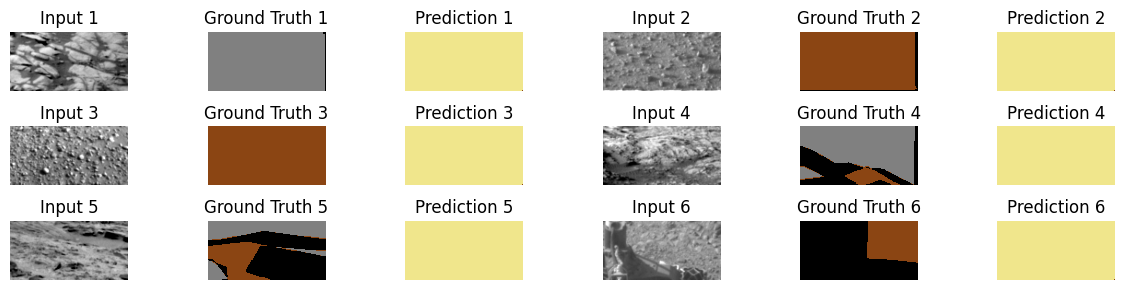

69/69 ━━━━━━━━━━━━━━━━━━━━ 272s 2s/step - accuracy: 0.3754 - loss: 0.9699 - mean_iou: 0.2069 - val_accuracy: 0.2171 - val_loss: 4.7231 - val_mean_iou: 0.0715 - learning_rate: 0.0010
Epoch 2/1000
69/69 ━━━━━━━━━━━━━━━━━━━━ 22s 312ms/step - accuracy: 0.5888 - loss: 0.4636 - mean_iou: 0.3860 - val_accuracy: 0.2171 - val_loss: 3.9471 - val_mean_iou: 0.0715 - learning_rate: 0.0010
Epoch 3/1000
69/69 ━━━━━━━━━━━━━━━━━━━━ 21s 298ms/step - accuracy: 0.6071 - loss: 0.4174 - mean_iou: 0.4036 - val_accuracy: 0.2171 - val_loss: 5.3913 - val_mean_iou: 0.0715 - learning_rate: 0.0010
Epoch 4/1000
69/69 ━━━━━━━━━━━━━━━━━━━━ 20s 294ms/step - accuracy: 0.6152 - loss: 0.3836 - mean_iou: 0.4130 - val_accuracy: 0.2171 - val_loss: 4.6787 - val_mean_iou: 0.0715 - learning_rate: 0.0010
Epoch 5/1000
69/69 ━━━━━━━━━━━━━━━━━━━━ 21s 300ms/step - accuracy: 0.6198 - loss: 0.3719 - mean_iou: 0.4192 - val_accuracy: 0.2738 - val_loss: 3.8927 - val_mean_iou: 0.1185 - learning_rate: 0.0010
Epoch 6/1000
69/69 ━━━━━━━━━━━

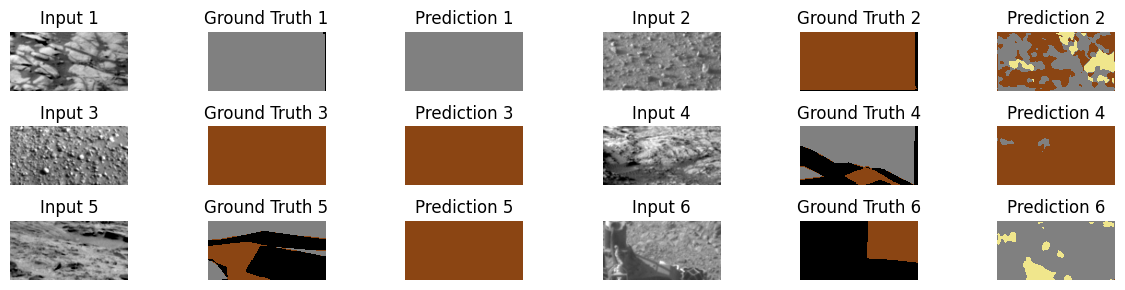

69/69 ━━━━━━━━━━━━━━━━━━━━ 22s 317ms/step - accuracy: 0.6533 - loss: 0.2789 - mean_iou: 0.5831 - val_accuracy: 0.5162 - val_loss: 2.3940 - val_mean_iou: 0.3906 - learning_rate: 0.0010
Epoch 12/1000
69/69 ━━━━━━━━━━━━━━━━━━━━ 21s 296ms/step - accuracy: 0.6590 - loss: 0.2543 - mean_iou: 0.5830 - val_accuracy: 0.4597 - val_loss: 2.7783 - val_mean_iou: 0.3280 - learning_rate: 0.0010
Epoch 13/1000
69/69 ━━━━━━━━━━━━━━━━━━━━ 21s 299ms/step - accuracy: 0.6507 - loss: 0.2759 - mean_iou: 0.5709 - val_accuracy: 0.4989 - val_loss: 2.8583 - val_mean_iou: 0.3437 - learning_rate: 0.0010
Epoch 14/1000
69/69 ━━━━━━━━━━━━━━━━━━━━ 21s 299ms/step - accuracy: 0.6596 - loss: 0.2554 - mean_iou: 0.5838 - val_accuracy: 0.4978 - val_loss: 2.5533 - val_mean_iou: 0.3694 - learning_rate: 0.0010
Epoch 15/1000
69/69 ━━━━━━━━━━━━━━━━━━━━ 21s 299ms/step - accuracy: 0.6591 - loss: 0.2490 - mean_iou: 0.5892 - val_accuracy: 0.4989 - val_loss: 2.5649 - val_mean_iou: 0.3769 - learning_rate: 0.0010
Epoch 16/1000
69/69 ━━━━

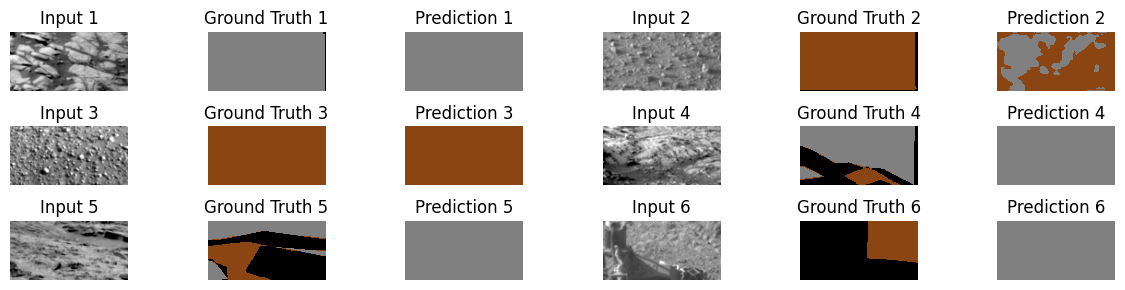

69/69 ━━━━━━━━━━━━━━━━━━━━ 22s 315ms/step - accuracy: 0.6672 - loss: 0.2321 - mean_iou: 0.5978 - val_accuracy: 0.5284 - val_loss: 2.8408 - val_mean_iou: 0.4021 - learning_rate: 0.0010
Epoch 22/1000
69/69 ━━━━━━━━━━━━━━━━━━━━ 21s 297ms/step - accuracy: 0.6748 - loss: 0.2074 - mean_iou: 0.6092 - val_accuracy: 0.4942 - val_loss: 2.6463 - val_mean_iou: 0.3624 - learning_rate: 0.0010
Epoch 23/1000
69/69 ━━━━━━━━━━━━━━━━━━━━ 21s 299ms/step - accuracy: 0.6800 - loss: 0.1962 - mean_iou: 0.6191 - val_accuracy: 0.6135 - val_loss: 2.6698 - val_mean_iou: 0.5029 - learning_rate: 0.0010
Epoch 24/1000
69/69 ━━━━━━━━━━━━━━━━━━━━ 21s 297ms/step - accuracy: 0.6829 - loss: 0.1936 - mean_iou: 0.6244 - val_accuracy: 0.5809 - val_loss: 2.8220 - val_mean_iou: 0.4662 - learning_rate: 0.0010
Epoch 25/1000
69/69 ━━━━━━━━━━━━━━━━━━━━ 21s 297ms/step - accuracy: 0.6808 - loss: 0.1892 - mean_iou: 0.6203 - val_accuracy: 0.5232 - val_loss: 3.0417 - val_mean_iou: 0.3949 - learning_rate: 0.0010
Epoch 26/1000
69/69 ━━━━

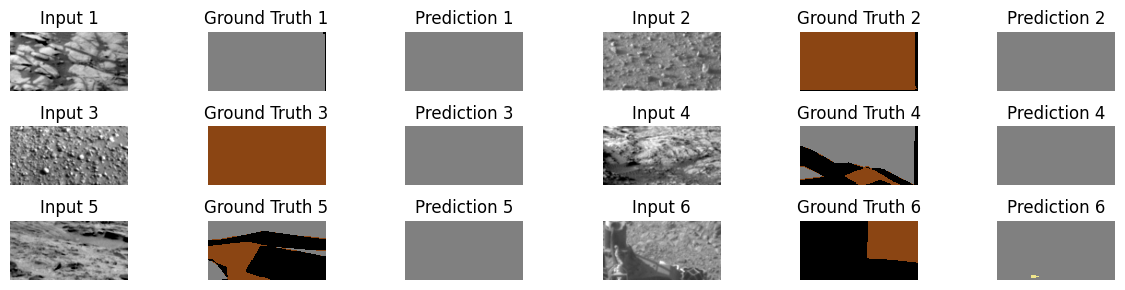

69/69 ━━━━━━━━━━━━━━━━━━━━ 22s 322ms/step - accuracy: 0.6911 - loss: 0.1711 - mean_iou: 0.6388 - val_accuracy: 0.3659 - val_loss: 4.1580 - val_mean_iou: 0.2349 - learning_rate: 0.0010
Epoch 32/1000
69/69 ━━━━━━━━━━━━━━━━━━━━ 21s 297ms/step - accuracy: 0.6947 - loss: 0.1539 - mean_iou: 0.6479 - val_accuracy: 0.3690 - val_loss: 4.1310 - val_mean_iou: 0.2433 - learning_rate: 0.0010
Epoch 33/1000
69/69 ━━━━━━━━━━━━━━━━━━━━ 21s 299ms/step - accuracy: 0.6930 - loss: 0.1645 - mean_iou: 0.6425 - val_accuracy: 0.6197 - val_loss: 2.6233 - val_mean_iou: 0.5073 - learning_rate: 0.0010
Epoch 34/1000
69/69 ━━━━━━━━━━━━━━━━━━━━ 21s 298ms/step - accuracy: 0.6934 - loss: 0.1630 - mean_iou: 0.6447 - val_accuracy: 0.3692 - val_loss: 4.3594 - val_mean_iou: 0.2362 - learning_rate: 0.0010
Epoch 35/1000
69/69 ━━━━━━━━━━━━━━━━━━━━ 21s 296ms/step - accuracy: 0.6961 - loss: 0.1575 - mean_iou: 0.6511 - val_accuracy: 0.3632 - val_loss: 4.3340 - val_mean_iou: 0.2427 - learning_rate: 0.0010
Epoch 36/1000
69/69 ━━━━

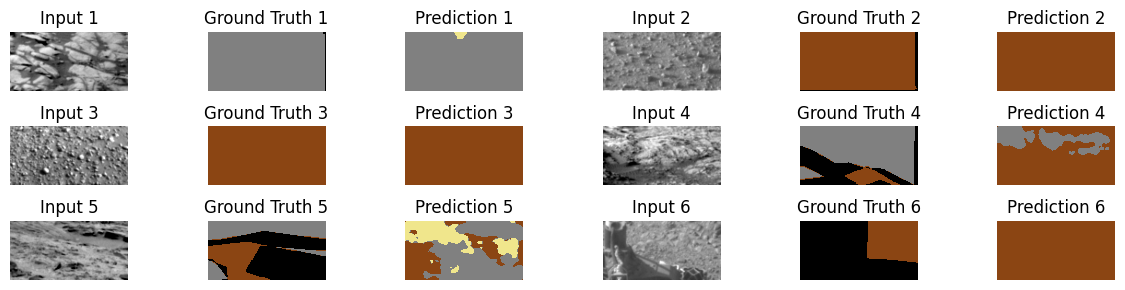

69/69 ━━━━━━━━━━━━━━━━━━━━ 22s 310ms/step - accuracy: 0.7005 - loss: 0.1429 - mean_iou: 0.6570 - val_accuracy: 0.6060 - val_loss: 3.0928 - val_mean_iou: 0.4747 - learning_rate: 0.0010
Epoch 42/1000
69/69 ━━━━━━━━━━━━━━━━━━━━ 20s 293ms/step - accuracy: 0.6938 - loss: 0.1585 - mean_iou: 0.6490 - val_accuracy: 0.3982 - val_loss: 4.1284 - val_mean_iou: 0.2598 - learning_rate: 0.0010
Epoch 43/1000
69/69 ━━━━━━━━━━━━━━━━━━━━ 21s 295ms/step - accuracy: 0.7071 - loss: 0.1235 - mean_iou: 0.6834 - val_accuracy: 0.6353 - val_loss: 2.8869 - val_mean_iou: 0.5278 - learning_rate: 0.0010
Epoch 44/1000
69/69 ━━━━━━━━━━━━━━━━━━━━ 20s 294ms/step - accuracy: 0.7045 - loss: 0.1330 - mean_iou: 0.6693 - val_accuracy: 0.6286 - val_loss: 2.9366 - val_mean_iou: 0.5226 - learning_rate: 0.0010
Epoch 45/1000
69/69 ━━━━━━━━━━━━━━━━━━━━ 20s 292ms/step - accuracy: 0.7055 - loss: 0.1249 - mean_iou: 0.6703 - val_accuracy: 0.6040 - val_loss: 3.1422 - val_mean_iou: 0.4773 - learning_rate: 0.0010
Epoch 46/1000
69/69 ━━━━

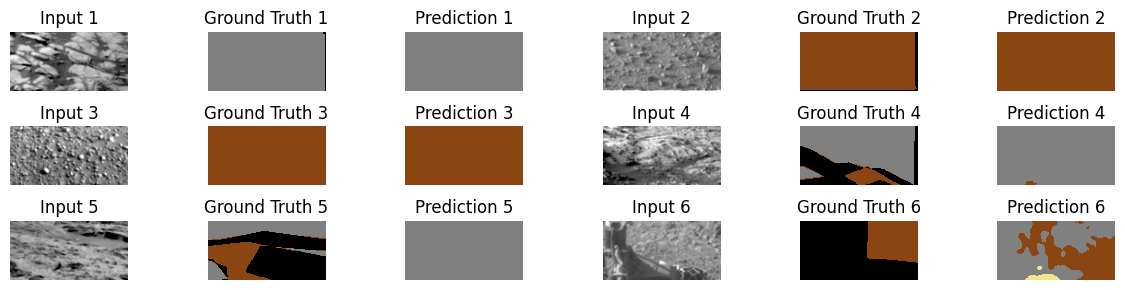

69/69 ━━━━━━━━━━━━━━━━━━━━ 22s 312ms/step - accuracy: 0.7086 - loss: 0.1189 - mean_iou: 0.6858 - val_accuracy: 0.6329 - val_loss: 3.0693 - val_mean_iou: 0.5330 - learning_rate: 0.0010
Epoch 52/1000
69/69 ━━━━━━━━━━━━━━━━━━━━ 20s 291ms/step - accuracy: 0.7137 - loss: 0.1022 - mean_iou: 0.6906 - val_accuracy: 0.6170 - val_loss: 3.2066 - val_mean_iou: 0.5294 - learning_rate: 0.0010
Epoch 53/1000
69/69 ━━━━━━━━━━━━━━━━━━━━ 20s 293ms/step - accuracy: 0.7117 - loss: 0.1161 - mean_iou: 0.6871 - val_accuracy: 0.3139 - val_loss: 6.1259 - val_mean_iou: 0.1804 - learning_rate: 0.0010
Epoch 54/1000
69/69 ━━━━━━━━━━━━━━━━━━━━ 20s 294ms/step - accuracy: 0.6981 - loss: 0.1400 - mean_iou: 0.6560 - val_accuracy: 0.3748 - val_loss: 4.9745 - val_mean_iou: 0.2410 - learning_rate: 0.0010
Epoch 55/1000
69/69 ━━━━━━━━━━━━━━━━━━━━ 21s 295ms/step - accuracy: 0.7142 - loss: 0.1056 - mean_iou: 0.6888 - val_accuracy: 0.3475 - val_loss: 6.0990 - val_mean_iou: 0.2087 - learning_rate: 0.0010
Epoch 56/1000
69/69 ━━━━

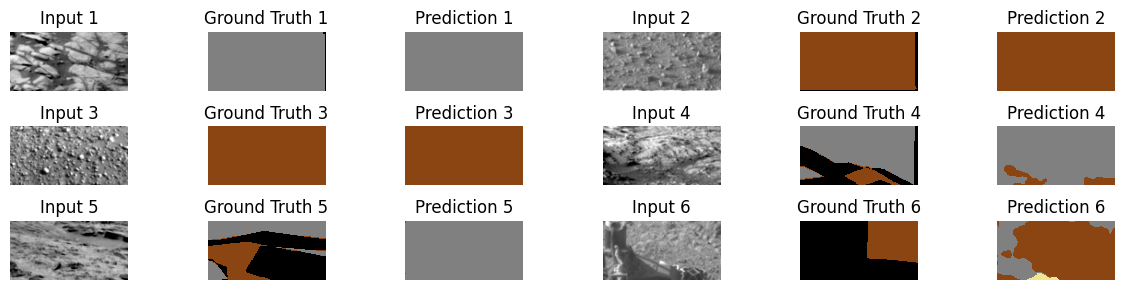

69/69 ━━━━━━━━━━━━━━━━━━━━ 22s 310ms/step - accuracy: 0.7122 - loss: 0.1126 - mean_iou: 0.6874 - val_accuracy: 0.5981 - val_loss: 3.0373 - val_mean_iou: 0.4841 - learning_rate: 0.0010
Epoch 62/1000
69/69 ━━━━━━━━━━━━━━━━━━━━ 20s 293ms/step - accuracy: 0.7118 - loss: 0.1130 - mean_iou: 0.6870 - val_accuracy: 0.6673 - val_loss: 2.9256 - val_mean_iou: 0.5805 - learning_rate: 0.0010
Epoch 63/1000
69/69 ━━━━━━━━━━━━━━━━━━━━ 20s 294ms/step - accuracy: 0.7171 - loss: 0.0933 - mean_iou: 0.7106 - val_accuracy: 0.6678 - val_loss: 2.9259 - val_mean_iou: 0.5819 - learning_rate: 0.0010
Epoch 64/1000
69/69 ━━━━━━━━━━━━━━━━━━━━ 20s 294ms/step - accuracy: 0.7178 - loss: 0.0930 - mean_iou: 0.7162 - val_accuracy: 0.4409 - val_loss: 4.3909 - val_mean_iou: 0.3269 - learning_rate: 0.0010
Epoch 65/1000
69/69 ━━━━━━━━━━━━━━━━━━━━ 20s 291ms/step - accuracy: 0.7195 - loss: 0.0867 - mean_iou: 0.7281 - val_accuracy: 0.6226 - val_loss: 3.2026 - val_mean_iou: 0.5192 - learning_rate: 0.0010
Epoch 66/1000
69/69 ━━━━

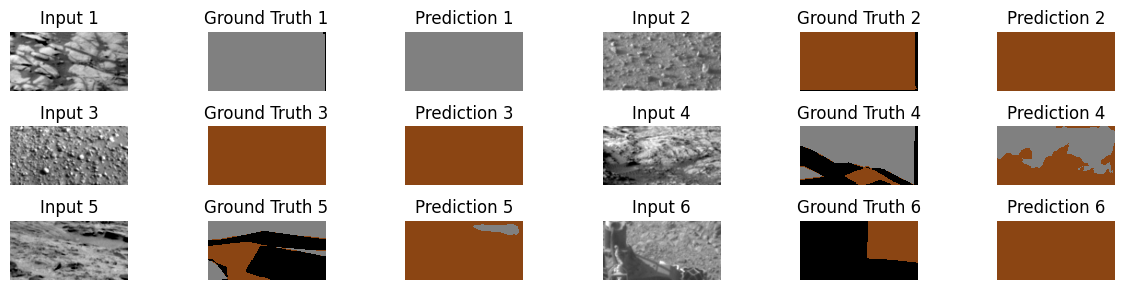

69/69 ━━━━━━━━━━━━━━━━━━━━ 21s 309ms/step - accuracy: 0.7183 - loss: 0.0950 - mean_iou: 0.7626 - val_accuracy: 0.6260 - val_loss: 2.9369 - val_mean_iou: 0.5580 - learning_rate: 0.0010
Epoch 72/1000
69/69 ━━━━━━━━━━━━━━━━━━━━ 20s 292ms/step - accuracy: 0.7264 - loss: 0.0753 - mean_iou: 0.7803 - val_accuracy: 0.6430 - val_loss: 3.3391 - val_mean_iou: 0.5489 - learning_rate: 0.0010
Epoch 73/1000
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 285ms/step - accuracy: 0.7256 - loss: 0.0691 - mean_iou: 0.8046
Epoch 73: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
69/69 ━━━━━━━━━━━━━━━━━━━━ 20s 292ms/step - accuracy: 0.7257 - loss: 0.0691 - mean_iou: 0.8043 - val_accuracy: 0.6474 - val_loss: 3.2629 - val_mean_iou: 0.5516 - learning_rate: 0.0010
Epoch 74/1000
69/69 ━━━━━━━━━━━━━━━━━━━━ 20s 291ms/step - accuracy: 0.7283 - loss: 0.0694 - mean_iou: 0.8026 - val_accuracy: 0.6388 - val_loss: 3.1101 - val_mean_iou: 0.5432 - learning_rate: 5.0000e-04
Epoch 75/1000
69/69 ━━━━━━━━━━━━━━━━━━━━ 20s 29

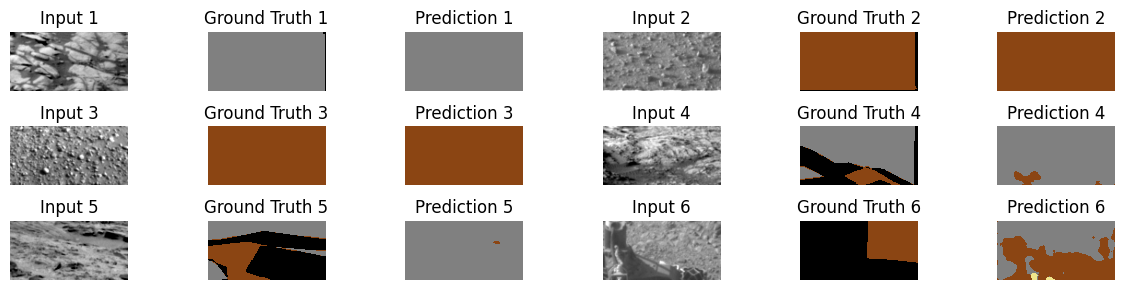

69/69 ━━━━━━━━━━━━━━━━━━━━ 22s 316ms/step - accuracy: 0.7341 - loss: 0.0539 - mean_iou: 0.8617 - val_accuracy: 0.6515 - val_loss: 3.2918 - val_mean_iou: 0.5614 - learning_rate: 5.0000e-04
Epoch 82/1000
69/69 ━━━━━━━━━━━━━━━━━━━━ 20s 291ms/step - accuracy: 0.7325 - loss: 0.0533 - mean_iou: 0.8607 - val_accuracy: 0.6643 - val_loss: 3.2813 - val_mean_iou: 0.5791 - learning_rate: 5.0000e-04
Epoch 83/1000
69/69 ━━━━━━━━━━━━━━━━━━━━ 20s 292ms/step - accuracy: 0.7355 - loss: 0.0487 - mean_iou: 0.8701 - val_accuracy: 0.6657 - val_loss: 3.2848 - val_mean_iou: 0.5819 - learning_rate: 5.0000e-04
Epoch 84/1000
69/69 ━━━━━━━━━━━━━━━━━━━━ 20s 292ms/step - accuracy: 0.7350 - loss: 0.0456 - mean_iou: 0.8721 - val_accuracy: 0.6330 - val_loss: 3.4087 - val_mean_iou: 0.5385 - learning_rate: 5.0000e-04
Epoch 85/1000
69/69 ━━━━━━━━━━━━━━━━━━━━ 20s 292ms/step - accuracy: 0.7332 - loss: 0.0470 - mean_iou: 0.8752 - val_accuracy: 0.6739 - val_loss: 3.3917 - val_mean_iou: 0.6258 - learning_rate: 5.0000e-04
Epoc

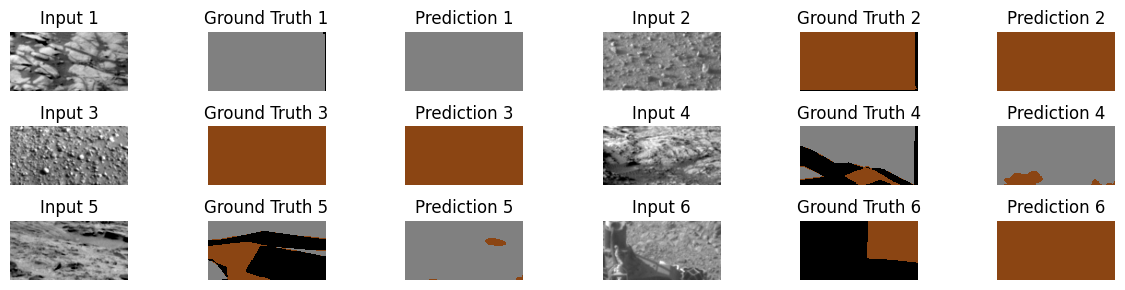

69/69 ━━━━━━━━━━━━━━━━━━━━ 21s 303ms/step - accuracy: 0.7401 - loss: 0.0388 - mean_iou: 0.9001 - val_accuracy: 0.6702 - val_loss: 3.3415 - val_mean_iou: 0.6090 - learning_rate: 5.0000e-04
Epoch 92/1000
69/69 ━━━━━━━━━━━━━━━━━━━━ 20s 291ms/step - accuracy: 0.7373 - loss: 0.0433 - mean_iou: 0.9075 - val_accuracy: 0.5837 - val_loss: 4.0764 - val_mean_iou: 0.4921 - learning_rate: 5.0000e-04
Epoch 93/1000
69/69 ━━━━━━━━━━━━━━━━━━━━ 20s 291ms/step - accuracy: 0.7302 - loss: 0.0657 - mean_iou: 0.8625 - val_accuracy: 0.6728 - val_loss: 3.4431 - val_mean_iou: 0.6046 - learning_rate: 5.0000e-04
Epoch 94/1000
69/69 ━━━━━━━━━━━━━━━━━━━━ 20s 291ms/step - accuracy: 0.7369 - loss: 0.0447 - mean_iou: 0.8977 - val_accuracy: 0.5719 - val_loss: 3.6939 - val_mean_iou: 0.4630 - learning_rate: 5.0000e-04
Epoch 95/1000
69/69 ━━━━━━━━━━━━━━━━━━━━ 20s 292ms/step - accuracy: 0.7381 - loss: 0.0399 - mean_iou: 0.9036 - val_accuracy: 0.6746 - val_loss: 3.3382 - val_mean_iou: 0.6168 - learning_rate: 5.0000e-04
Epoc

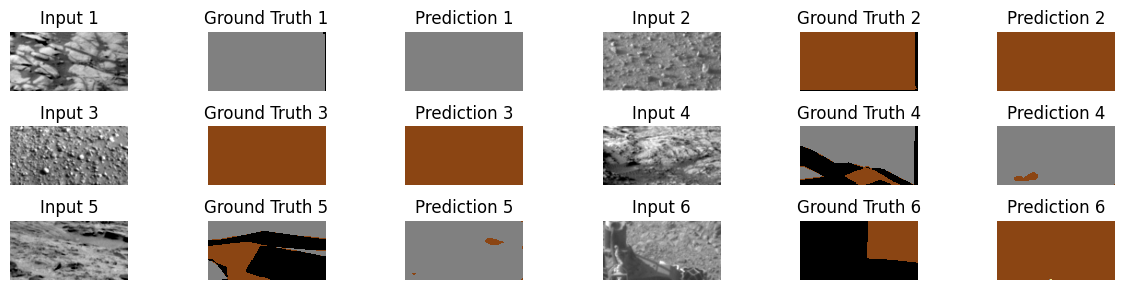

69/69 ━━━━━━━━━━━━━━━━━━━━ 21s 304ms/step - accuracy: 0.7394 - loss: 0.0334 - mean_iou: 0.9217 - val_accuracy: 0.6691 - val_loss: 3.5495 - val_mean_iou: 0.6076 - learning_rate: 2.5000e-04
Epoch 102/1000
69/69 ━━━━━━━━━━━━━━━━━━━━ 20s 289ms/step - accuracy: 0.7401 - loss: 0.0346 - mean_iou: 0.9186 - val_accuracy: 0.6710 - val_loss: 3.5166 - val_mean_iou: 0.6012 - learning_rate: 2.5000e-04
Epoch 103/1000
69/69 ━━━━━━━━━━━━━━━━━━━━ 20s 291ms/step - accuracy: 0.7417 - loss: 0.0310 - mean_iou: 0.9248 - val_accuracy: 0.6680 - val_loss: 3.5960 - val_mean_iou: 0.6101 - learning_rate: 2.5000e-04
Epoch 104/1000
69/69 ━━━━━━━━━━━━━━━━━━━━ 20s 291ms/step - accuracy: 0.7390 - loss: 0.0319 - mean_iou: 0.9272 - val_accuracy: 0.6755 - val_loss: 3.5711 - val_mean_iou: 0.6483 - learning_rate: 2.5000e-04
Epoch 105/1000
69/69 ━━━━━━━━━━━━━━━━━━━━ 20s 291ms/step - accuracy: 0.7417 - loss: 0.0314 - mean_iou: 0.9262 - val_accuracy: 0.6747 - val_loss: 3.5382 - val_mean_iou: 0.6290 - learning_rate: 2.5000e-04


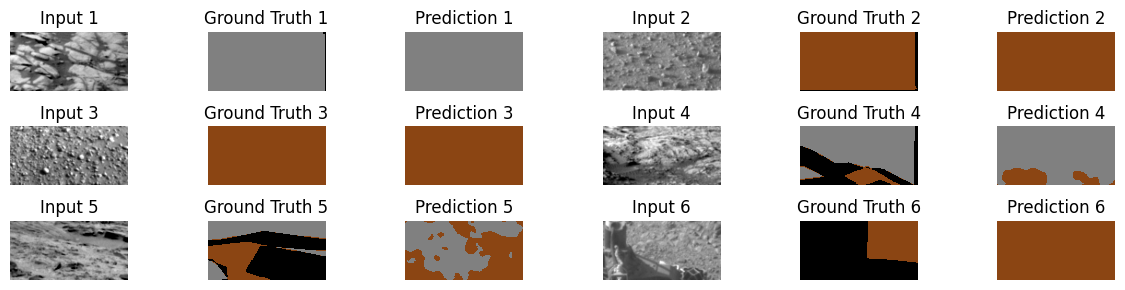

69/69 ━━━━━━━━━━━━━━━━━━━━ 21s 306ms/step - accuracy: 0.7420 - loss: 0.0267 - mean_iou: 0.9363 - val_accuracy: 0.6734 - val_loss: 3.5895 - val_mean_iou: 0.6448 - learning_rate: 2.5000e-04
Epoch 112/1000
69/69 ━━━━━━━━━━━━━━━━━━━━ 20s 289ms/step - accuracy: 0.7436 - loss: 0.0275 - mean_iou: 0.9359 - val_accuracy: 0.6672 - val_loss: 3.6419 - val_mean_iou: 0.6038 - learning_rate: 2.5000e-04
Epoch 113/1000
69/69 ━━━━━━━━━━━━━━━━━━━━ 20s 290ms/step - accuracy: 0.7439 - loss: 0.0266 - mean_iou: 0.9303 - val_accuracy: 0.6629 - val_loss: 3.6437 - val_mean_iou: 0.6314 - learning_rate: 2.5000e-04
Epoch 114/1000
69/69 ━━━━━━━━━━━━━━━━━━━━ 20s 291ms/step - accuracy: 0.7436 - loss: 0.0273 - mean_iou: 0.9247 - val_accuracy: 0.6657 - val_loss: 3.6420 - val_mean_iou: 0.6467 - learning_rate: 2.5000e-04
Epoch 115/1000
69/69 ━━━━━━━━━━━━━━━━━━━━ 20s 291ms/step - accuracy: 0.7445 - loss: 0.0273 - mean_iou: 0.9323 - val_accuracy: 0.6720 - val_loss: 3.6408 - val_mean_iou: 0.6355 - learning_rate: 2.5000e-04


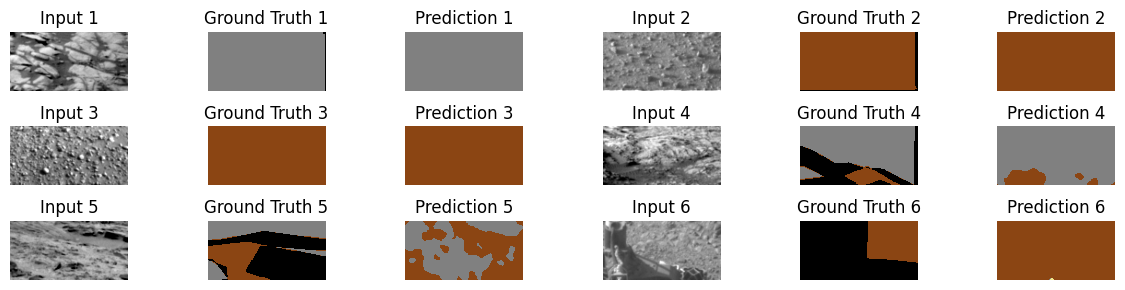

69/69 ━━━━━━━━━━━━━━━━━━━━ 21s 307ms/step - accuracy: 0.7435 - loss: 0.0229 - mean_iou: 0.9483 - val_accuracy: 0.6685 - val_loss: 3.6734 - val_mean_iou: 0.6212 - learning_rate: 1.2500e-04
Epoch 122/1000
69/69 ━━━━━━━━━━━━━━━━━━━━ 20s 289ms/step - accuracy: 0.7431 - loss: 0.0235 - mean_iou: 0.9520 - val_accuracy: 0.6730 - val_loss: 3.6705 - val_mean_iou: 0.6508 - learning_rate: 1.2500e-04
Epoch 123/1000
69/69 ━━━━━━━━━━━━━━━━━━━━ 20s 290ms/step - accuracy: 0.7438 - loss: 0.0224 - mean_iou: 0.9574 - val_accuracy: 0.6726 - val_loss: 3.6411 - val_mean_iou: 0.6489 - learning_rate: 1.2500e-04
Epoch 124/1000
69/69 ━━━━━━━━━━━━━━━━━━━━ 20s 291ms/step - accuracy: 0.7442 - loss: 0.0225 - mean_iou: 0.9558 - val_accuracy: 0.6712 - val_loss: 3.6406 - val_mean_iou: 0.6488 - learning_rate: 1.2500e-04
Epoch 125/1000
69/69 ━━━━━━━━━━━━━━━━━━━━ 20s 290ms/step - accuracy: 0.7426 - loss: 0.0223 - mean_iou: 0.9505 - val_accuracy: 0.6717 - val_loss: 3.6349 - val_mean_iou: 0.6456 - learning_rate: 1.2500e-04


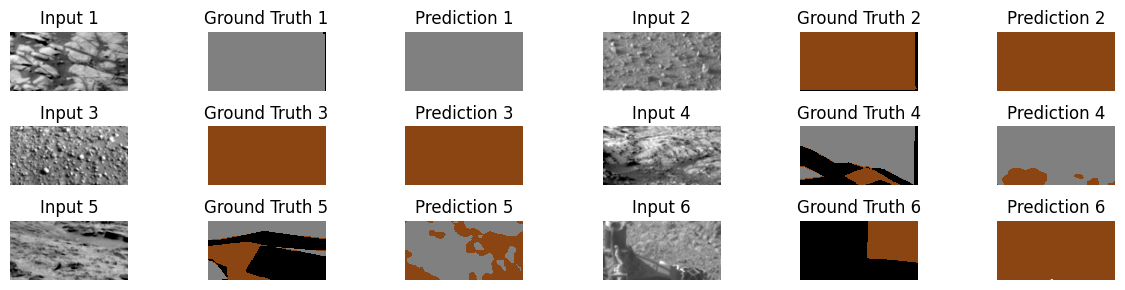

69/69 ━━━━━━━━━━━━━━━━━━━━ 22s 316ms/step - accuracy: 0.7451 - loss: 0.0212 - mean_iou: 0.9572 - val_accuracy: 0.6732 - val_loss: 3.6655 - val_mean_iou: 0.6493 - learning_rate: 6.2500e-05
Epoch 132/1000
69/69 ━━━━━━━━━━━━━━━━━━━━ 20s 289ms/step - accuracy: 0.7441 - loss: 0.0212 - mean_iou: 0.9542 - val_accuracy: 0.6735 - val_loss: 3.6909 - val_mean_iou: 0.6514 - learning_rate: 6.2500e-05
Epoch 133/1000
69/69 ━━━━━━━━━━━━━━━━━━━━ 20s 289ms/step - accuracy: 0.7435 - loss: 0.0209 - mean_iou: 0.9581 - val_accuracy: 0.6714 - val_loss: 3.7186 - val_mean_iou: 0.6371 - learning_rate: 6.2500e-05
Epoch 134/1000
69/69 ━━━━━━━━━━━━━━━━━━━━ 20s 289ms/step - accuracy: 0.7423 - loss: 0.0210 - mean_iou: 0.9558 - val_accuracy: 0.6693 - val_loss: 3.7155 - val_mean_iou: 0.6424 - learning_rate: 6.2500e-05
Epoch 135/1000
69/69 ━━━━━━━━━━━━━━━━━━━━ 20s 290ms/step - accuracy: 0.7450 - loss: 0.0210 - mean_iou: 0.9554 - val_accuracy: 0.6712 - val_loss: 3.7069 - val_mean_iou: 0.6449 - learning_rate: 6.2500e-05


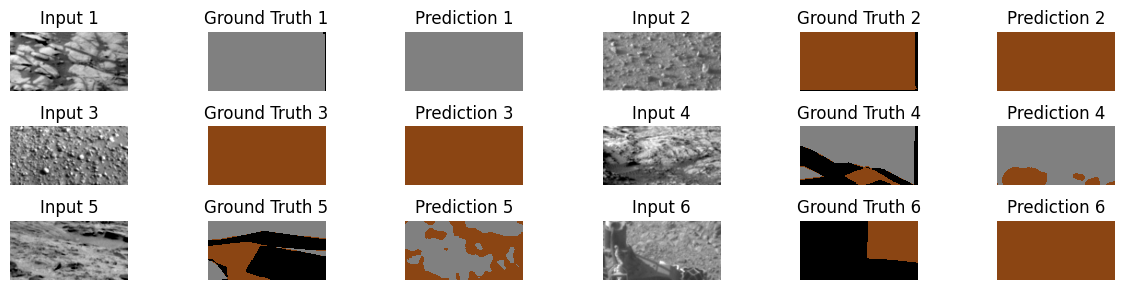

69/69 ━━━━━━━━━━━━━━━━━━━━ 21s 307ms/step - accuracy: 0.7442 - loss: 0.0207 - mean_iou: 0.9573 - val_accuracy: 0.6731 - val_loss: 3.7007 - val_mean_iou: 0.6489 - learning_rate: 3.1250e-05
Epoch 142/1000
69/69 ━━━━━━━━━━━━━━━━━━━━ 20s 289ms/step - accuracy: 0.7440 - loss: 0.0209 - mean_iou: 0.9549 - val_accuracy: 0.6716 - val_loss: 3.7058 - val_mean_iou: 0.6445 - learning_rate: 3.1250e-05
Epoch 143/1000
69/69 ━━━━━━━━━━━━━━━━━━━━ 20s 290ms/step - accuracy: 0.7459 - loss: 0.0197 - mean_iou: 0.9618 - val_accuracy: 0.6685 - val_loss: 3.7270 - val_mean_iou: 0.6370 - learning_rate: 3.1250e-05
Epoch 144/1000
69/69 ━━━━━━━━━━━━━━━━━━━━ 20s 290ms/step - accuracy: 0.7439 - loss: 0.0204 - mean_iou: 0.9625 - val_accuracy: 0.6733 - val_loss: 3.6954 - val_mean_iou: 0.6474 - learning_rate: 3.1250e-05
Epoch 145/1000
69/69 ━━━━━━━━━━━━━━━━━━━━ 20s 290ms/step - accuracy: 0.7453 - loss: 0.0197 - mean_iou: 0.9627 - val_accuracy: 0.6716 - val_loss: 3.7125 - val_mean_iou: 0.6457 - learning_rate: 3.1250e-05


In [16]:
mean_iou = tfk.metrics.MeanIoU(num_classes=5, ignore_class=0, sparse_y_pred=False, name='mean_iou')

model.compile(
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    optimizer=tf.keras.optimizers.AdamW(LEARNING_RATE),
    metrics=["accuracy", mean_iou]
)
print("Model compiled!")

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_mean_iou',
    mode='max',
    patience=PATIENCE,
    restore_best_weights=True
)

lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_mean_iou', mode='max', factor=0.5, patience=10, min_lr=1e-5, verbose=1
)

n = 6
viz_callback = VizCallback(val_dataset, frequency=10, n=n)

history = model.fit(
    train_dataset,
    epochs=EPOCHS,
    validation_data=val_dataset,
    callbacks=[lr_scheduler, early_stopping, viz_callback],
    verbose=1,
    class_weight={0:0, 1:1, 2:1, 3:1, 4:1} #class_weights_dict
).history

final_val_meanIoU = round(max(history['val_mean_iou'])* 100, 2)
print(f'Final validation Mean Intersection Over Union: {final_val_meanIoU}%')

In [17]:
model_filename = f'Simple_Double_UNet_{str(final_val_meanIoU)}_aug4_0class0.keras'

if (on_kaggle):
    model_filename = f"/kaggle/working/{model_filename}"

model.save(model_filename)
print(f"Model saved to {model_filename}")

Model saved to /kaggle/working/Simple_Double_UNet_65.34_aug4_0class0.keras


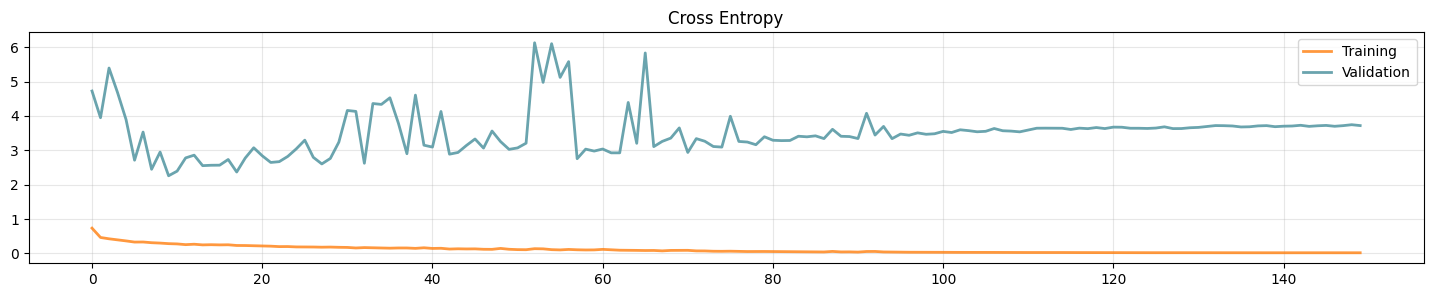

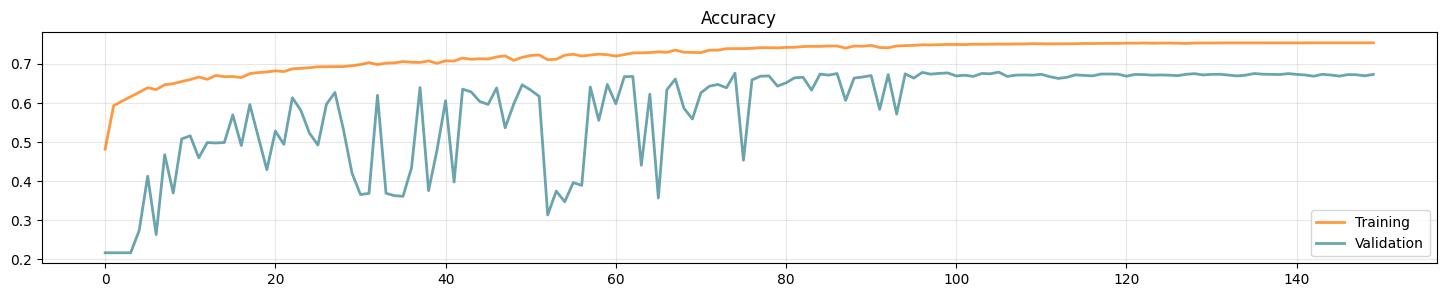

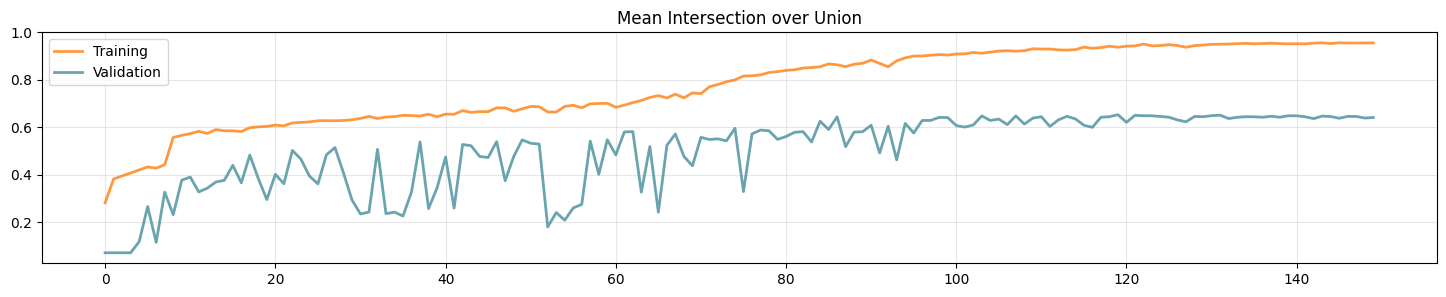

In [18]:
plt.figure(figsize=(18, 3))
plt.plot(history['loss'], label='Training', alpha=0.8, color='#ff7f0e', linewidth=2)
plt.plot(history['val_loss'], label='Validation', alpha=0.9, color='#5a9aa5', linewidth=2)
plt.title('Cross Entropy')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(18, 3))
plt.plot(history['accuracy'], label='Training', alpha=0.8, color='#ff7f0e', linewidth=2)
plt.plot(history['val_accuracy'], label='Validation', alpha=0.9, color='#5a9aa5', linewidth=2)
plt.title('Accuracy')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(18, 3))
plt.plot(history['mean_iou'], label='Training', alpha=0.8, color='#ff7f0e', linewidth=2)
plt.plot(history['val_mean_iou'], label='Validation', alpha=0.9, color='#5a9aa5', linewidth=2)
plt.title('Mean Intersection over Union')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 📊 Prepare Your Submission

In our Kaggle competition, submissions are made as `csv` files. To create a proper `csv` file, you need to flatten your predictions and include an `id` column as the first column of your dataframe. To maintain consistency between your results and our solution, please avoid shuffling the test set. The code below demonstrates how to prepare the `csv` file from your model predictions.



Model loaded from /kaggle/working/Simple_Double_UNet_65.34_aug4_0class0.keras
314/314 ━━━━━━━━━━━━━━━━━━━━ 18s 53ms/step
Predictions shape: (10022, 64, 128)
Class counts: [       0 36818183 27214050 17982303    85688]


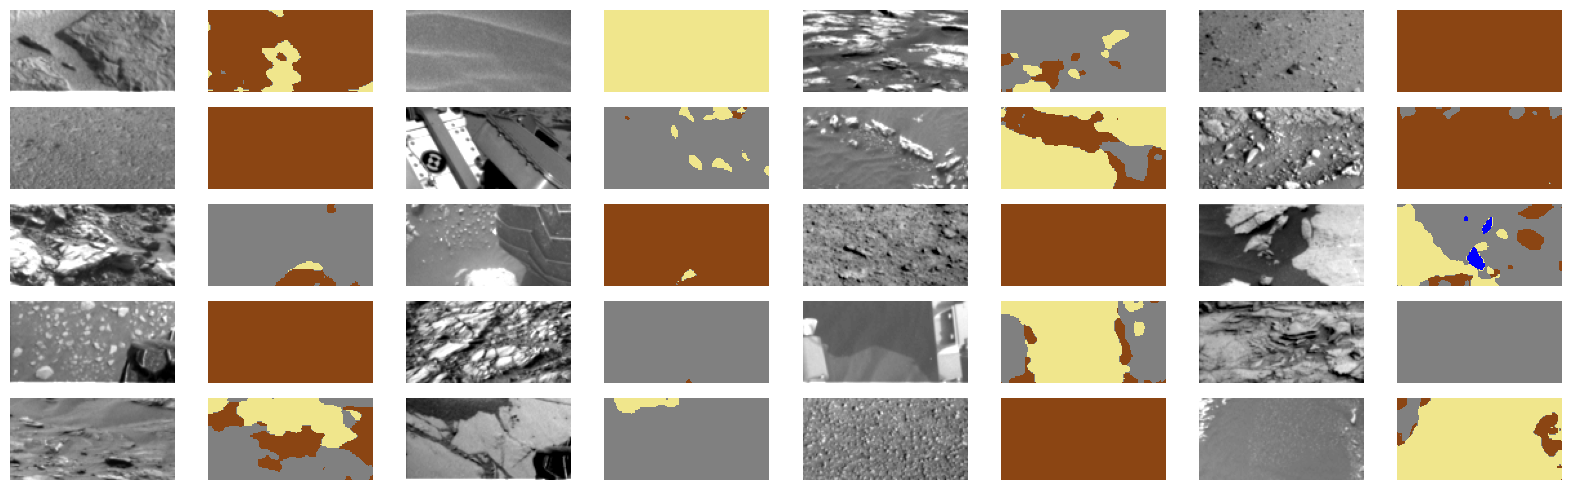

In [19]:
model_pred = tfk.models.load_model(model_filename)
print(f"Model loaded from {model_filename}")

X_test = apply_preprocessing(X_test_original) 
X_test = tf.cast(X_test, tf.float32)

preds = model_pred.predict(X_test)
preds = np.argmax(preds, axis=-1)
class_counts = np.bincount(preds.flatten(), minlength=5)

print(f"Predictions shape: {preds.shape}")
print(f"Class counts: {class_counts}")
plot_image_label(X_test, preds, 5, 4, 1)

In [20]:
def y_to_df(y) -> pd.DataFrame:
    n_samples = len(y)
    y_flat = y.reshape(n_samples, -1)
    df = pd.DataFrame(y_flat)
    df["id"] = np.arange(n_samples)
    cols = ["id"] + [col for col in df.columns if col != "id"]
    return df[cols]

submission_df = y_to_df(preds)
submission_filename = model_filename.replace(".keras", ".csv")
zip_filename = model_filename.replace(".keras", ".zip")
submission_df.to_csv(submission_filename, index=False)

with zipfile.ZipFile(zip_filename, 'w', zipfile.ZIP_DEFLATED) as zipf:
    filename = submission_filename.replace("/kaggle/working/", "")
    zipf.write(submission_filename, arcname=filename)

os.remove(submission_filename)
print("Zip file with CSV created successfully!")

Zip file with CSV created successfully!
